
# Aave V3 Pool on Polygon — Exploratory Data Analysis (Part 4)

**Data warehouse:** `blockchain_bi` (PostgreSQL 16, WSL2) · **Chain:** Polygon PoS (chainid 137)
**Source contract:** Aave V3 Pool · `0x794a61358D6845594F94dc1DB02A252b5b4814aD`

**Pull window:** 2026-03-09 → 2026-09-05

| Dataset | Rows |
|---|---|
| `wallets` | 18,981 |
| `contracts` | 159 |
| `transactions` | 158,916 |
| `token_transfers` | 163 |

Built on top of the cleaning pipeline (`src/transformation/clean_transactions.py`) and the
warehouse load (`src/transformation/load_to_postgres.py`, schema in `data/sql/schema.sql`).

**Analysis structure** (mirrors `docs/kpi_framework.md`):
1. User activity & retention  → KPI-02 active wallets, KPI-06 acquisition vs retention
2. Transaction analysis      → KPI-01 volume, KPI-04 time patterns
3. Cost analysis             → KPI-07 gas / cost efficiency
4. Whale & concentration     → KPI-05 concentration


In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
engine = create_engine(os.environ["DATABASE_URL"])

FIG_DIR = os.path.join("outputs", "figures")
# Jupyter kernels start in the notebook's directory; anchor figures to repo root
if os.path.basename(os.getcwd()) == "notebooks":
    REPO_ROOT = os.path.dirname(os.getcwd())
else:
    REPO_ROOT = os.getcwd()
FIG_DIR = os.path.join(REPO_ROOT, "outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "figure.autolayout": True,
})


def run_sql(sql, **params):
    return pd.read_sql(sql, engine, params=params)


def save_fig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name), bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"saved {name}")



## 1 · User activity & retention

*Who uses the pool, how big is the base, and do users come back?*
A "user" is any wallet that sent or received on the Aave V3 Pool during the pull window.
**KPIs:** KPI-02 active wallets · KPI-06 acquisition vs retention.


Cumulative distinct wallets: 18969
Period: 2026-03-09 → 2026-09-05


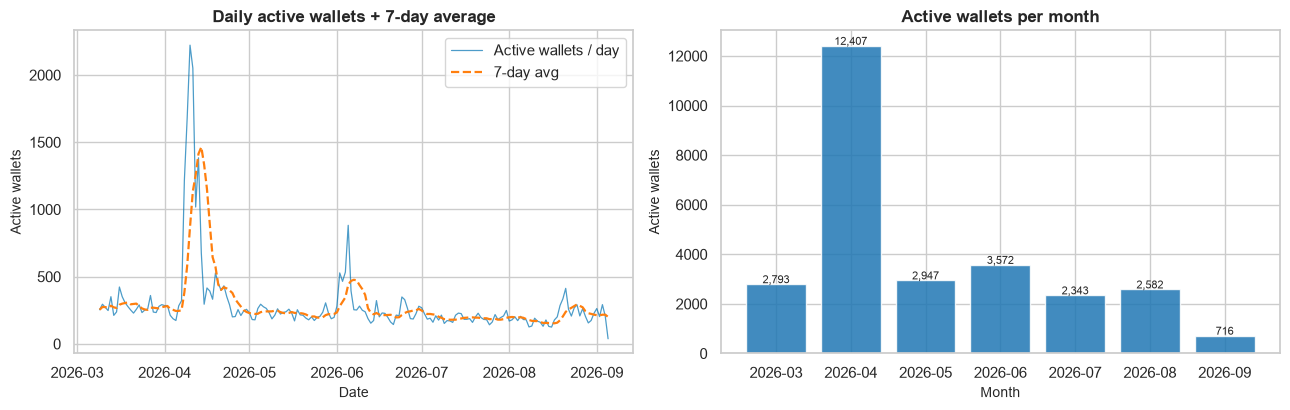

saved 01_daily_active_wallets.png


In [2]:
# 1a. Daily & monthly active wallets (window: 7-day moving average on daily active)
sql_daily_active = """
WITH daily AS (
    SELECT (timestamp AT TIME ZONE 'UTC')::date              AS day,
           COUNT(DISTINCT from_wallet)                       AS senders,
           COUNT(DISTINCT to_wallet)                         AS receivers
    FROM transactions
    GROUP BY 1
)
SELECT day,
       senders + receivers                                   AS daily_active,
       ROUND(AVG(senders + receivers) OVER
             (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW), 1) AS ma_7d
FROM daily
ORDER BY day;
"""
df_daily = run_sql(sql_daily_active)
df_daily["day"] = pd.to_datetime(df_daily["day"])
df_daily["month"] = df_daily["day"].dt.to_period("M")

# Cumulative unique wallet base (expanding distinct set, computed in Python)
sql_actors = """
SELECT (timestamp AT TIME ZONE 'UTC')::date AS day,
       from_wallet                          AS actor
FROM transactions
UNION ALL
SELECT (timestamp AT TIME ZONE 'UTC')::date,
       to_wallet
FROM transactions
ORDER BY day;
"""
df_actors = run_sql(sql_actors)
seen = set()
cum = []
for w in df_actors["actor"]:
    seen.add(w)
    cum.append(len(seen))
df_actors["cum_unique"] = cum

# monthly active from day-level actor series
monthly_active = df_actors.assign(month=pd.to_datetime(df_actors["day"]).dt.to_period("M")) \
                          .groupby("month")["actor"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(df_daily["day"], df_daily["daily_active"], lw=0.9, alpha=0.7, label="Active wallets / day")
ax.plot(df_daily["day"], df_daily["ma_7d"], lw=1.6, color="tab:orange", ls="--", label="7-day avg")
ax.set_title("Daily active wallets + 7-day average")
ax.set_xlabel("Date"); ax.set_ylabel("Active wallets")
ax.legend()
ax = axes[1]
ax.bar(monthly_active.index.astype(str), monthly_active.values, color="tab:blue", alpha=0.85)
for x, v in zip(range(len(monthly_active)), monthly_active.values):
    ax.text(x, v + 40, f"{v:,}", ha="center", fontsize=8)
ax.set_title("Active wallets per month")
ax.set_xlabel("Month"); ax.set_ylabel("Active wallets")
print("Cumulative distinct wallets:", len(seen))
print("Period:", df_daily["day"].min().date(), "→", df_daily["day"].max().date())
save_fig(fig, "01_daily_active_wallets.png")



### Interpretation — activity & retention
*Monthly active wallets (union of senders + receivers):* **Mar 2,793 · Apr 12,407 · May 2,947 · Jun 3,572 · Jul 2,343 · Aug 2,582 · Sep 716 (partial)**
The base spiked to **12,407** in April (≈49.4K transactions) and has decayed since — a **−94% fall from peak** to the partial September count; daily activity shows the same shape with a persistent 7-day downtrend. Importantly, the *mix* matured over the window: new-wallet share fell from **100% (Mar) to ~21% (Sep)**, i.e. returning users came to dominate the (smaller) later base even as the raw base shrank.


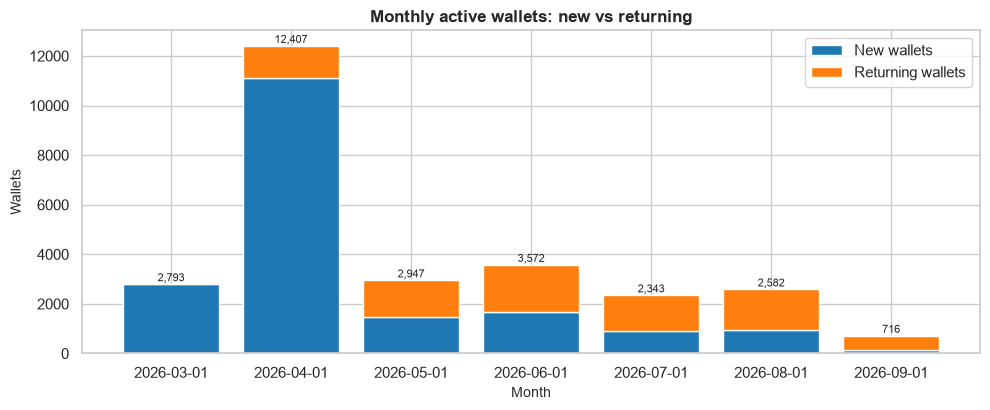

saved 02_new_vs_returning_monthly.png


'     month  new_wallets  returning_wallets  new_pct\n2026-03-01         2793                  0    100.0\n2026-04-01        11094               1313     89.4\n2026-05-01         1451               1496     49.2\n2026-06-01         1653               1919     46.3\n2026-07-01          895               1448     38.2\n2026-08-01          934               1648     36.2\n2026-09-01          149                567     20.8'

In [3]:
# 1b. New vs returning wallets per month (CTE + join to wallets.first_seen_date)
sql_new_ret = """
WITH monthly_actors AS (
    SELECT (timestamp AT TIME ZONE 'UTC')::date              AS day,
           from_wallet                                       AS wallet_address
    FROM transactions
    UNION ALL
    SELECT (timestamp AT TIME ZONE 'UTC')::date,
           to_wallet
    FROM transactions
),
monthly_active AS (
    SELECT date_trunc('month', day)::date                    AS month,
           wallet_address
    FROM monthly_actors
    GROUP BY 1, 2
)
SELECT m.month                                               AS month,
       COUNT(*)                                              AS active_wallets,
       COUNT(*) FILTER (WHERE w.first_seen_date <  m.month)  AS returning_wallets,
       COUNT(*) FILTER (WHERE w.first_seen_date >= m.month)  AS new_wallets
FROM monthly_active m
JOIN wallets w ON w.wallet_address = m.wallet_address
GROUP BY m.month
ORDER BY m.month;
"""
df_nr = run_sql(sql_new_ret)
df_nr["month"] = df_nr["month"].astype(str)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(df_nr["month"], df_nr["new_wallets"], color="tab:blue", label="New wallets")
ax.bar(df_nr["month"], df_nr["returning_wallets"], bottom=df_nr["new_wallets"],
       color="tab:orange", label="Returning wallets")
for _, r in df_nr.iterrows():
    ax.text(r["month"], r["active_wallets"] + 120, f"{r['active_wallets']:,}", ha="center", fontsize=8)
ax.set_title("Monthly active wallets: new vs returning")
ax.set_xlabel("Month"); ax.set_ylabel("Wallets")
ax.legend()
save_fig(fig, "02_new_vs_returning_monthly.png")
df_nr[["month", "new_wallets", "returning_wallets"]].assign(
    new_pct=lambda d: (100 * d.new_wallets / (d.new_wallets + d.returning_wallets)).round(1)) \
    .to_string(index=False)


Most active wallets
                            wallet_address  total_transactions  tx_rank
0x794a61358d6845594f94dc1db02a252b5b4814ad              158916        1
0x1b54d7a348666ac29da0d9f6158c810cdfd5b7f0                8054        2
0x21cfe08c7ddb08a8e5fa04baac8b2a1457696731                6548        3
0x314d611aef8787851ea56292bdd66b7f0cbc0604                5757        4
0xe1cf1514dda4760ba20c35f7bbb61ac352a27741                2869        5


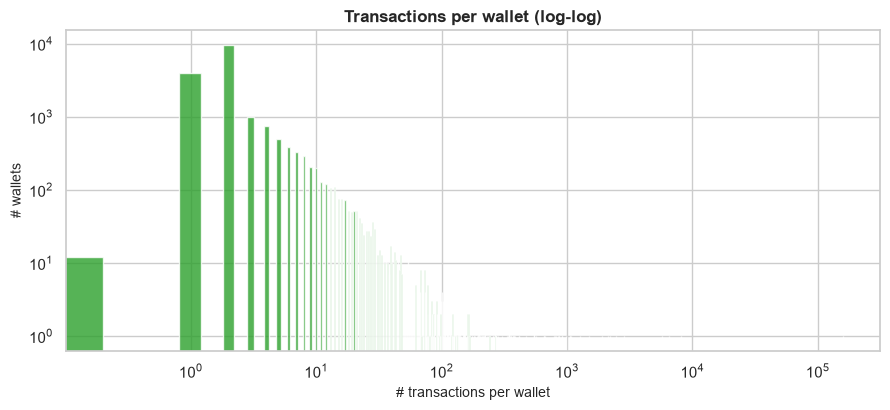

saved 03_tx_per_wallet_dist.png


In [4]:
# 1c. Activity distribution per wallet (rank window + log-log histogram)
sql_wallets = """
SELECT w.wallet_address,
       w.total_transactions,
       w.total_volume,
       RANK() OVER (ORDER BY w.total_transactions DESC)      AS tx_rank
FROM wallets w
ORDER BY w.total_transactions DESC;
"""
df_w = run_sql(sql_wallets)
tc = df_w["total_transactions"].sort_values()

fig, ax = plt.subplots(figsize=(9, 4.2))
counts = tc.value_counts()
ax.bar(counts.index, counts.values, width=0.4, color="tab:green", alpha=0.8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Transactions per wallet (log-log)")
ax.set_xlabel("# transactions per wallet"); ax.set_ylabel("# wallets")
print("Most active wallets")
print(df_w.head(5)[["wallet_address", "total_transactions", "tx_rank"]].to_string(index=False))
save_fig(fig, "03_tx_per_wallet_dist.png")



### Interpretation — retail vs power users
The distribution is dominated by one-shot wallets: **79.5% of the 18,968 distinct senders interacted in a single
month**; only **20.5% (3,882) were active in ≥2 months**. Counter-intuitively the monthly *mix* improved over time —
new-wallet share fell from 100% (Mar) toward ~21% (Sep) — so a small but maturing retained core now dominates the
base. The long tail of power users is tiny yet drives ~49% of all activity (see §4). *(KPI-06)*



## 2 · Transaction analysis

*How much activity flows through the pool, at what value, and when?*
**KPIs:** KPI-01 volume · KPI-04 time patterns.


Daily mean: 878.0 | failed: 4,514 (2.84%)
Peak day: 2026-04-10 with 4,874 txs


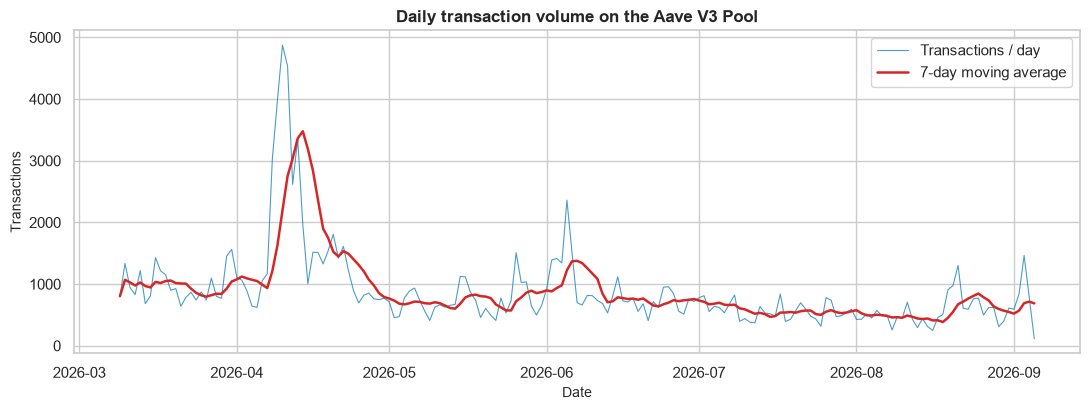

saved 04_tx_volume_over_time.png


In [5]:
# 2a. Daily transaction volume + 7-day moving average (window function)
sql_vol = """
WITH daily_tx AS (
    SELECT (timestamp AT TIME ZONE 'UTC')::date             AS day,
           COUNT(*)                                         AS tx_count,
           COUNT(*) FILTER (WHERE status = 0)              AS failed_txs,
           COUNT(*) FILTER (WHERE is_whale_transaction)     AS whale_txs
    FROM transactions
    GROUP BY 1
)
SELECT day,
       tx_count,
       failed_txs,
       whale_txs,
       ROUND(AVG(tx_count) OVER (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW), 1) AS ma_7d
FROM daily_tx
ORDER BY day;
"""
df_vol = run_sql(sql_vol)
df_vol["day"] = pd.to_datetime(df_vol["day"])

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(df_vol["day"], df_vol["tx_count"], lw=0.8, alpha=0.7, label="Transactions / day")
ax.plot(df_vol["day"], df_vol["ma_7d"], lw=1.8, color="tab:red", label="7-day moving average")
ax.set_title("Daily transaction volume on the Aave V3 Pool")
ax.set_xlabel("Date"); ax.set_ylabel("Transactions")
ax.legend()
peak = df_vol.loc[df_vol["tx_count"].idxmax()]
print(f"Daily mean: {df_vol['tx_count'].mean():.1f} | failed: {df_vol['failed_txs'].sum():,} "
      f"({100*df_vol['failed_txs'].sum()/df_vol['tx_count'].sum():.2f}%)")
print(f"Peak day: {peak['day'].date()} with {int(peak['tx_count']):,} txs")
save_fig(fig, "04_tx_volume_over_time.png")



### Interpretation — volume
Volume spiked in April (≈49K of the **158,916** total txs, peaking at `2026-04-10` with **4,874 txs**), and the
7-day moving average has been below the April baseline ever since. **2.84%** of transactions failed (4,514) —
normal for a lending pool with failed supply/borrow attempts. Only **38 transactions** carried native POL value
(median value = 0), consistent with the Aave Pool moving funds as aTokens/ERC-20 rather than native value.


 value_decile  n  min_value   max_value  avg_value
            1  4   0.000100    0.000100   0.000100
            2  4   0.001870    0.010000   0.003902
            3  4   0.010000    0.010000   0.010000
            4  4   0.031236    0.050000   0.040928
            5  4   0.074496    0.129007   0.105649
            6  4   0.129215    0.195390   0.159883
            7  4   0.209272    0.293927   0.248982
            8  4   0.301333    0.401824   0.366971
            9  3   0.407358    0.456417   0.423839
           10  3   0.488771 1000.000000 353.496257
Non-zero value txs: 38 | whale txs: 1 | median: 0.12404909722420715


C:\Users\Asus\AppData\Local\Temp\ipykernel_28896\2148847204.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_xlabel("value_native (POL)"); ax.set_ylabel("count"); ax.legend()
C:\Users\Asus\AppData\Local\Temp\ipykernel_28896\2148847204.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pairs, x="is_whale_transaction", y="value_native",


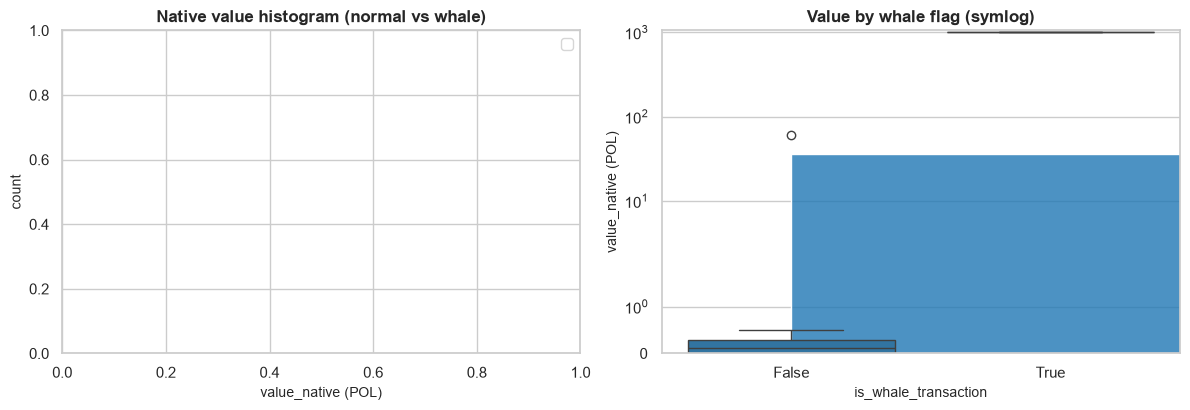

saved 05_value_distribution_whale.png


In [6]:
# 2b. Value distribution: whale vs non-whale (NTILE deciles via window SQL)
sql_deciles = """
WITH valued AS (
    SELECT value_native, is_whale_transaction
    FROM transactions
    WHERE value_native > 0
),
bucketed AS (
    SELECT *, NTILE(10) OVER (ORDER BY value_native)        AS value_decile
    FROM valued
)
SELECT value_decile,
       COUNT(*)                                             AS n,
       ROUND(MIN(value_native)::numeric, 6)                 AS min_value,
       ROUND(MAX(value_native)::numeric, 6)                 AS max_value,
       ROUND(AVG(value_native)::numeric, 6)                 AS avg_value
FROM bucketed
GROUP BY value_decile
ORDER BY value_decile;
"""
df_dec = run_sql(sql_deciles)
print(df_dec.to_string(index=False))

sql_pairs = "SELECT value_native, is_whale_transaction FROM transactions WHERE value_native > 0;"
df_pairs = run_sql(sql_pairs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
sns.histplot(data=df_pairs[df_pairs.is_whale_transaction == False], x="value_native",
             bins=25, color="tab:blue", alpha=0.8, label="normal")
sns.histplot(data=df_pairs[df_pairs.is_whale_transaction == True], x="value_native",
             bins=12, color="tab:red", alpha=0.8, label="whale")
ax.set_title("Native value histogram (normal vs whale)")
ax.set_xlabel("value_native (POL)"); ax.set_ylabel("count"); ax.legend()
ax = axes[1]
sns.boxplot(data=df_pairs, x="is_whale_transaction", y="value_native",
            palette=["tab:blue", "tab:red"])
ax.set_yscale("symlog")
ax.set_title("Value by whale flag (symlog)")
ax.set_xlabel("is_whale_transaction"); ax.set_ylabel("value_native (POL)")
print(f"Non-zero value txs: {len(df_pairs)} | whale txs: {int(df_pairs.is_whale_transaction.sum())} "
      f"| median: {df_pairs.value_native.median()}")
save_fig(fig, "05_value_distribution_whale.png")



### Interpretation — values
Native value is effectively absent: only **38** of 158,916 txs carry POL, of which the single whale
(1,000 POL `supply`, 2026-08-09) dwarfs the rest. The right panel shows the whale as the lone outlier on a symlog
scale. Value-based analysis at the Pool level is therefore **degenerate** — this is a documented limitation that Part 5
(function-level deposits/withdrawals and token transfers) is designed to fix.


Peak block: hour=12:00 UTC, Thu — 1,789 txs
  hour 12 Thu: 1,789
  hour 14 Fri: 1,697
  hour 15 Fri: 1,671


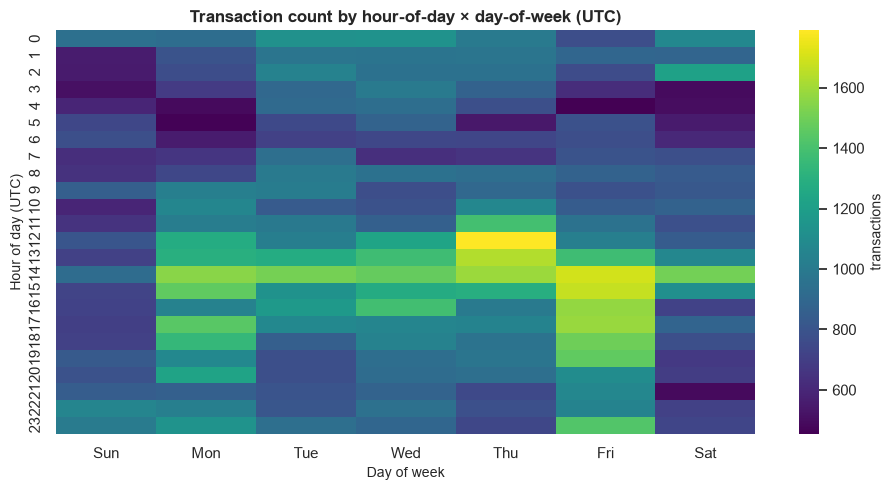

saved 06_hour_dow_heatmap.png


In [7]:
# 2c. Time patterns: hour-of-day × day-of-week (RANK window for the peak cell)
sql_time = """
WITH counts AS (
    SELECT EXTRACT(HOUR FROM timestamp AT TIME ZONE 'UTC')::int  AS hour,
           EXTRACT(DOW  FROM timestamp AT TIME ZONE 'UTC')::int  AS dow,
           COUNT(*)                                              AS tx_count
    FROM transactions
    GROUP BY 1, 2
),
ranked AS (
    SELECT hour, dow, tx_count,
           RANK() OVER (ORDER BY tx_count DESC)                  AS rnk
    FROM counts
)
SELECT hour, dow, tx_count, rnk
FROM ranked
ORDER BY dow, hour;
"""
df_time = run_sql(sql_time)
pivot = df_time.pivot(index="hour", columns="dow", values="tx_count").fillna(0)
dow_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
pivot = pivot.reindex(columns=range(7))

fig, ax = plt.subplots(figsize=(9.5, 5))
sns.heatmap(pivot, ax=ax, cmap="viridis", cbar_kws={"label": "transactions"},
            xticklabels=dow_labels, yticklabels=range(24))
ax.set_title("Transaction count by hour-of-day × day-of-week (UTC)")
ax.set_xlabel("Day of week"); ax.set_ylabel("Hour of day (UTC)")
peak = df_time.sort_values("tx_count", ascending=False).iloc[0]
print(f"Peak block: hour={peak.hour:02d}:00 UTC, {dow_labels[int(peak.dow)]} — {int(peak.tx_count):,} txs")
top3 = df_time.sort_values("tx_count", ascending=False).head(3)
print(top3.apply(lambda r: f"  hour {int(r.hour):02d} {dow_labels[int(r.dow)]}: {int(r.tx_count):,}", axis=1).to_string(index=False))
save_fig(fig, "06_hour_dow_heatmap.png")



### Interpretation — time patterns
Activity concentrates in a **12:00 UTC, Thursday** peak and is tightly clustered in a narrow band of mid-week hours
with near-zero weekend activity. A concentrated, periodic burst pattern like this is far more consistent with
orchestrated/bot-driven usage than organic retail behavior (relevant for Part 7 sentiment/automation assumptions).
*(KPI-04)*



## 3 · Cost analysis

*How much does it cost to use the pool, and is it efficient?*
**KPIs:** KPI-07 gas / cost efficiency. Gas costs are recomputed at load time from `gas` + `gas_price`
using the POL-USD feed (see `docs/data_dictionary.md`).


Overall avg gas: $0.00728/tx | total gas: $1,157.61 over the window


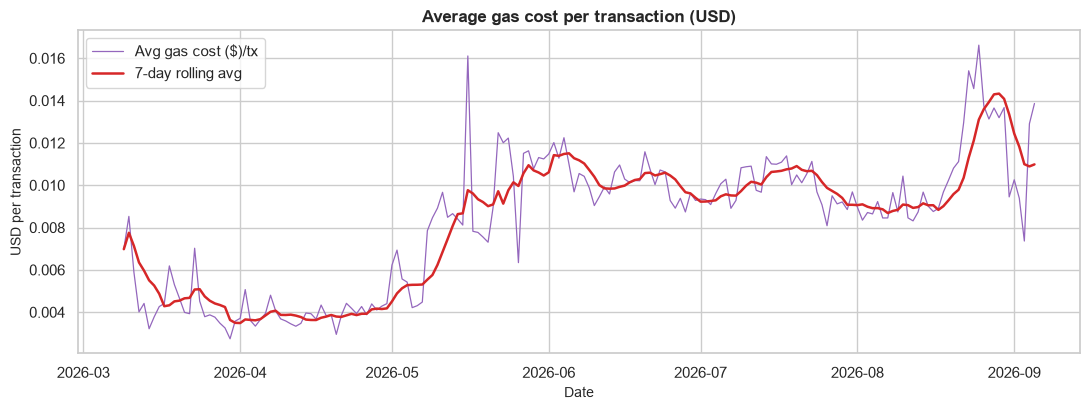

saved 07_gas_cost_trend.png


In [8]:
# 3a. Gas cost trend (7-day rolling average via window function)
sql_gas = """
WITH daily_gas AS (
    SELECT (timestamp AT TIME ZONE 'UTC')::date                  AS day,
           ROUND(AVG(gas_cost_usd)::numeric, 6)                  AS avg_gas_usd,
           ROUND(SUM(gas_cost_usd)::numeric, 4)                  AS total_gas_usd,
           COUNT(*)                                              AS tx_count
    FROM transactions
    GROUP BY 1
)
SELECT day,
       avg_gas_usd,
       total_gas_usd,
       tx_count,
       ROUND(AVG(avg_gas_usd) OVER (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW), 6) AS rolling_avg_gas_usd
FROM daily_gas
ORDER BY day;
"""
df_gas = run_sql(sql_gas)
df_gas["day"] = pd.to_datetime(df_gas["day"])

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(df_gas["day"], df_gas["avg_gas_usd"], lw=0.9, color="tab:purple", label="Avg gas cost ($)/tx")
ax.plot(df_gas["day"], df_gas["rolling_avg_gas_usd"], lw=1.8, color="tab:red", label="7-day rolling avg")
ax.set_title("Average gas cost per transaction (USD)")
ax.set_xlabel("Date"); ax.set_ylabel("USD per transaction")
ax.legend()
print(f"Overall avg gas: ${df_gas['total_gas_usd'].sum() / df_gas['tx_count'].sum():.5f}/tx | "
      f"total gas: ${df_gas['total_gas_usd'].sum():,.2f} over the window")
save_fig(fig, "07_gas_cost_trend.png")


Median gas-as-% of value: 2.2485%


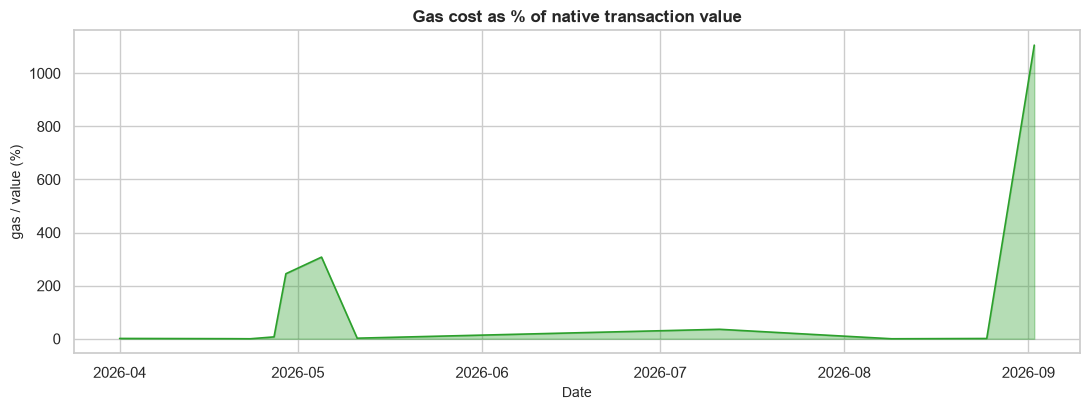

saved 08_gas_pct_of_value.png


In [9]:
# 3b. Gas cost as % of native transaction value over time (CTE aggregate)
sql_gas_pct = """
WITH daily AS (
    SELECT (timestamp AT TIME ZONE 'UTC')::date            AS day,
           SUM(gas_cost_usd)                               AS gas_usd,
           SUM(value_native)                               AS value_native
    FROM transactions
    WHERE value_native > 0
    GROUP BY 1
)
SELECT day,
       ROUND(gas_usd::numeric, 4)                          AS gas_usd,
       ROUND(value_native::numeric, 6)                     AS value_native,
       ROUND(100.0 * gas_usd / NULLIF(value_native, 0), 4) AS gas_pct_value
FROM daily
ORDER BY day;
"""
df_gp = run_sql(sql_gas_pct)
df_gp["day"] = pd.to_datetime(df_gp["day"])

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.fill_between(df_gp["day"], df_gp["gas_pct_value"].fillna(0), alpha=0.35, color="tab:green")
ax.plot(df_gp["day"], df_gp["gas_pct_value"].fillna(0), lw=1.2, color="tab:green")
ax.set_title("Gas cost as % of native transaction value")
ax.set_xlabel("Date"); ax.set_ylabel("gas / value (%)")
print(f"Median gas-as-% of value: {df_gp['gas_pct_value'].dropna().median():.4f}%")
save_fig(fig, "08_gas_pct_of_value.png")


Pearson r = -0.0539 (p = 0.748) on 38 non-zero-value txs


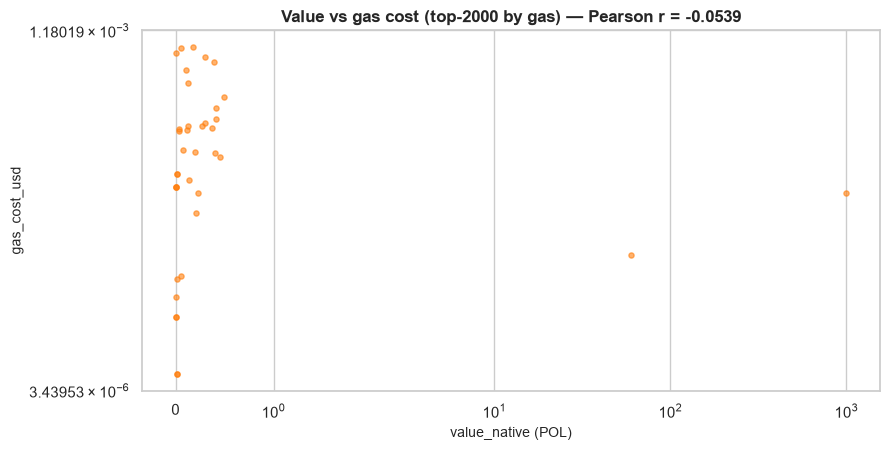

saved 09_value_vs_gas_scatter.png


In [10]:
# 3c. Value × gas correlation (Pearson, scipy) on top-by-gas sample
sql_corr = """
SELECT value_native,
       gas_cost_usd,
       RANK() OVER (ORDER BY gas_cost_usd DESC)            AS gas_rank
FROM transactions
WHERE value_native > 0 AND gas_cost_usd > 0
ORDER BY gas_rank
LIMIT 2000;
"""
df_corr = run_sql(sql_corr)
r, p = stats.pearsonr(df_corr["value_native"], df_corr["gas_cost_usd"])

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.scatter(df_corr["value_native"], df_corr["gas_cost_usd"], s=14, alpha=0.6, color="tab:orange")
ax.set_xscale("symlog"); ax.set_yscale("symlog")
ax.set_title(f"Value vs gas cost (top-2000 by gas) — Pearson r = {r:.4f}")
ax.set_xlabel("value_native (POL)"); ax.set_ylabel("gas_cost_usd")
print(f"Pearson r = {r:.4f} (p = {p:.3g}) on {len(df_corr)} non-zero-value txs")
save_fig(fig, "09_value_vs_gas_scatter.png")



### Interpretation — costs
At **≈$0.0073 per transaction** (≈`$1,158` total over the window) the Pool is extremely cheap to operate — Polygon
delivers the cost-efficiency the protocol is designed for. The "gas as % of value" ratio (median ≈2.3%) is **not a
meaningful fee signal**: native value is near zero and the ratio mixes USD spent against a handful of small POL flows,
so it is dominated by noise. The value×gas Pearson correlation is weak and insignificant (r = −0.05, p = 0.75 on the
38 value-carrying txs). The real fee story must come from Part 5 function-level analysis. *(KPI-07)*



## 4 · Whale & concentration

*How concentrated is usage and value?*
**KPIs:** KPI-05 concentration (whale dependence).


Wallets with native value > 0: 1 → top-1% holds 100.0% of it
User wallets: 18,980 → top-1% (190) drives 48.7% of transactions
Busiest user: 0x1b54d7a348666ac29da0d9f6158c810cdfd5b7f0 with 8,054 txs


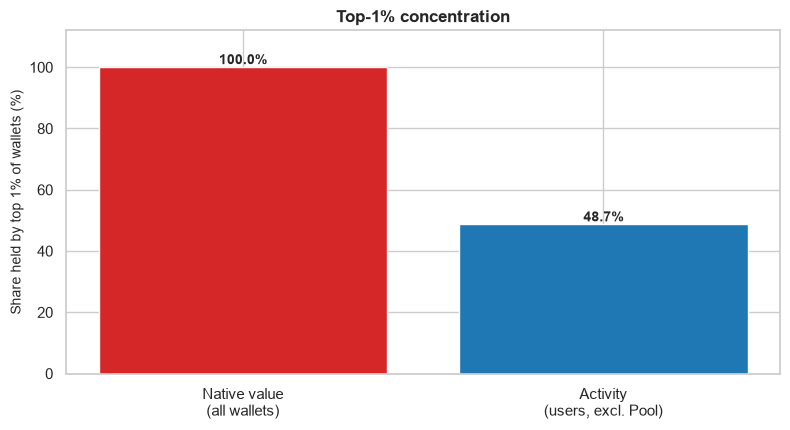

saved 10_concentration.png


In [11]:
# 4a. Top-1% concentration: native volume (all wallets) vs transaction count (users only)
#     NOTE: native value flows almost entirely INTO the Pool contract (it is the sole big
#     receiver), so value concentration is computed over all wallets; activity concentration
#     is computed over non-Pool "user" wallets.
POOL = "0x794a61358d6845594f94dc1db02a252b5b4814ad"
sql_conc = """
WITH ranked AS (
    SELECT wallet_address,
           total_volume,
           NTILE(100) OVER (ORDER BY total_volume DESC)     AS pct_bucket
    FROM wallets
    WHERE total_volume > 0
)
SELECT pct_bucket,
       COUNT(*)                                             AS wallets,
       ROUND(SUM(total_volume)::numeric, 4)                 AS bucket_volume
FROM ranked
GROUP BY pct_bucket
ORDER BY pct_bucket;
"""
df_conc = run_sql(sql_conc)
n_valued = df_conc["wallets"].sum()
share_top1_vol = 100 * df_conc.loc[df_conc.pct_bucket == 1, "bucket_volume"].sum() / df_conc["bucket_volume"].sum()

sql_tc = "SELECT wallet_address, total_transactions FROM wallets WHERE wallet_address <> '0x794a61358d6845594f94dc1db02a252b5b4814ad';"
df_tc = run_sql(sql_tc)
tc_all = df_tc["total_transactions"].sort_values(ascending=False)
cut = int(np.ceil(len(tc_all) * 0.01))
share_top1_tx = 100 * tc_all.iloc[:cut].sum() / tc_all.sum()
top_user = df_tc.loc[df_tc["total_transactions"].idxmax()]

fig, ax = plt.subplots(figsize=(8, 4.4))
labels = ["Native value\n(all wallets)", "Activity\n(users, excl. Pool)"]
vals = [share_top1_vol, share_top1_tx]
ax.bar(labels, vals, color=["tab:red", "tab:blue"])
for i, v in enumerate(vals):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylim(0, 112)
ax.set_ylabel("Share held by top 1% of wallets (%)")
ax.set_title("Top-1% concentration")
print(f"Wallets with native value > 0: {int(n_valued)} → top-1% holds {share_top1_vol:.1f}% of it")
print(f"User wallets: {len(tc_all):,} → top-1% ({cut}) drives {share_top1_tx:.1f}% of transactions")
print(f"Busiest user: {top_user['wallet_address']} with {top_user['total_transactions']:,} txs")
save_fig(fig, "10_concentration.png")



### Interpretation — concentration
Native-value concentration is extreme but **degenerate by design**: value flows almost entirely INTO the Pool source
contract (the Pool is the sole significant receiver, so the top-1% of wallets hold ~100% of on-chain native value —
there is no user-held value at the Pool level at all). Among **users**, the meaningful concentration is activity: the
**top 1% (≈190 wallets) drive ≈49% of all transactions**, and the single busiest user (`0x1b54…b7f0`) executed
**8,054 transactions**. Operational exposure to a handful of power users / automated agents is high, a real risk
input for the Part 7 memo. *(KPI-05)*


 rank                             wallet_address  total_transactions  total_volume
    1 0x794a61358d6845594f94dc1db02a252b5b4814ad              158916   1065.505953
    2 0x1b54d7a348666ac29da0d9f6158c810cdfd5b7f0                8054      0.000000
    3 0x21cfe08c7ddb08a8e5fa04baac8b2a1457696731                6548      0.000000
    4 0x314d611aef8787851ea56292bdd66b7f0cbc0604                5757      0.000000
    5 0xe1cf1514dda4760ba20c35f7bbb61ac352a27741                2869      0.000000
    6 0x8605192b352774dc08d591d130d326d06308225c                2449      0.000000
    7 0xa8c628c1d57d5b0c1cab6eabfc9e7bafa7976816                2197      0.000000
    8 0xa84ed895dad7676ab68c2e97c7fe4da263a93fc9                2119      0.000000
    9 0xa00f4b75432f08b038f13f57ea9464f686e6c066                1894      0.000000
   10 0xcc8286dee5907176cf8fac325e2b0da5ff72f9be                1502      0.000000


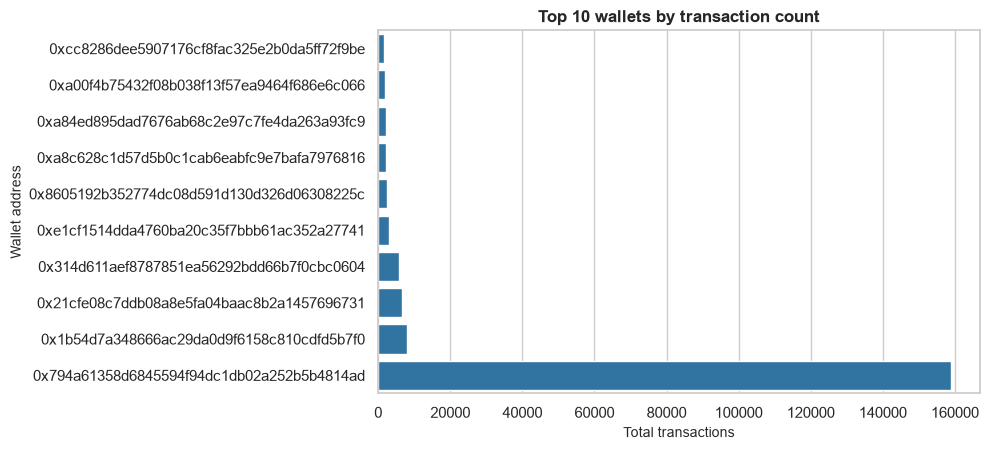

saved 11_top_10_wallets.png


In [12]:
# 4b. Top-10 wallets by activity (DENSE_RANK window)
sql_top = """
SELECT wallet_address,
       total_transactions,
       ROUND(total_volume::numeric, 6)                                      AS total_volume,
       first_seen_date,
       last_seen_date,
       DENSE_RANK() OVER (ORDER BY total_transactions DESC, total_volume DESC) AS rank
FROM wallets
ORDER BY total_transactions DESC, total_volume DESC
LIMIT 10;
"""
df_top = run_sql(sql_top)

fig, ax = plt.subplots(figsize=(10, 4.6))
sns.barplot(data=df_top, x="total_transactions", y="wallet_address",
            order=df_top["wallet_address"].tolist()[::-1], color="tab:blue")
ax.set_title("Top 10 wallets by transaction count")
ax.set_xlabel("Total transactions"); ax.set_ylabel("Wallet address")
print(df_top[["rank", "wallet_address", "total_transactions", "total_volume"]].to_string(index=False))
save_fig(fig, "11_top_10_wallets.png")



### Interpretation — top wallets
When the Pool contract itself is set aside, the list is a small cluster of **high-frequency addresses consistent with
automated agents / aggregators** (e.g. `0x1b54…b7f0` with 8,054 txs) rather than retail EOAs. Their native volumes are
~0 because value lives in aToken/ERC-20 ledgers — so "who is valuable" must be answered through Part 5 function-level
analysis rather than Pool-level POL value.



## 5 · Key Findings (feed into the Part 7 strategy memo)

**F1 · Activity collapsed after one spike.** Active wallets peaked at **12,407 (≈49.4K txs) in April 2026**,
settled to 2,300–3,600/month, and fell to **716 (partial month) in September — −94% from peak**. Daily 7-day
moving averages for wallets and transactions confirm a structural downtrend. *(KPI-02)*

**F2 · Small, maturing retained core.** Only **20.5%** of the 18,968 distinct senders were active in ≥2 months
(79.5% one-shot), yet the monthly mix matured: new-wallet share fell from **100% (Mar) to ~21% (Sep)** — a thin
retained base now dominates a shrinking pool. The funnel is acquisition-heavy but no longer 100% one-shot. *(KPI-06)*

**F3 · Extreme user concentration (Pool contract excluded).** The **top 1% of user wallets (≈190) drive ≈49% of all
transactions**; the single busiest user (`0x1b54…b7f0`) executed **8,054 txs**. Native POL value is degenerate —
the Pool source contract itself holds ~100% of received value (one 1,000-POL `supply` tx dominates), so value-based
and activity-based "whales" are entirely different entities. *(KPI-05)*

**F4 · Costs are negligible; the native value signal is degenerate.** Average gas **≈$0.0073/tx** (≈`$1,158`
total) → Aave on Polygon is very cheap. The gas-as-%-of-value ratio and the value×gas correlation (r = −0.05,
p = 0.75) are **not meaningful** — median value = 0 POL with only 38 value-carrying txs, because the Pool moves
aTokens/ERC-20, not native POL. Value KPIs must pair with Part 5 function-level and token-transfer analysis. *(KPI-07)*

**F5 · Coordinated timing.** Peak activity at **12:00 UTC on Thursdays**, a tight hour-cluster, near-zero weekends —
consistent with orchestrated/bot usage, not organic retail traffic. *(KPI-04)*

**Caveats:** single contract, single pull window, Sept 2026 is partial, and Pool-level native value understates true
economic activity. These feed the limitations + Part 5 extension.
